**Source:** https://www.kaggle.com/datasets/hasibullahaman/traffic-prediction-dataset/data

In [ ]:
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Download latest version
path = kagglehub.dataset_download("hasibullahaman/traffic-prediction-dataset")

print("Path to dataset files:", path)

csv_path = os.path.join(path, "TrafficTwoMonth.csv")
df = pd.read_csv(csv_path)

print(df.info())
print(df.head())
print(df.describe())
df.isnull().sum().sort_values(ascending=False)

Path to dataset files: /kaggle/input/traffic-prediction-dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5952 entries, 0 to 5951
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Time               5952 non-null   object
 1   Date               5952 non-null   int64 
 2   Day of the week    5952 non-null   object
 3   CarCount           5952 non-null   int64 
 4   BikeCount          5952 non-null   int64 
 5   BusCount           5952 non-null   int64 
 6   TruckCount         5952 non-null   int64 
 7   Total              5952 non-null   int64 
 8   Traffic Situation  5952 non-null   object
dtypes: int64(6), object(3)
memory usage: 418.6+ KB
None
          Time  Date Day of the week  CarCount  BikeCount  BusCount  \
0  12:00:00 AM    10         Tuesday        13          2         2   
1  12:15:00 AM    10         Tuesday        14          1         1   
2  12:30:00 AM    10         Tuesday       

,0
Time,0
Date,0
Day of the week,0
CarCount,0
BikeCount,0
BusCount,0
TruckCount,0
Total,0
Traffic Situation,0


In [ ]:
df['Day'] = df['Date'].astype(str).str.zfill(2)
df['Datetime'] = pd.to_datetime('2023-01-' + df['Day'] + ' ' + df['Time'], errors='coerce')
df['Day'] = df['Day'].astype(int)

df['Hour'] = df['Datetime'].dt.hour
df['Minute'] = df['Datetime'].dt.minute
df['DayOfWeek'] = df['Datetime'].dt.dayofweek
df['Month'] = df['Datetime'].dt.month

df.drop(columns=['Time', 'Date', 'Datetime', 'Day of the week'], inplace=True)

# Define custom order
custom_order = [['low', 'normal', 'high', 'heavy']]

# Reshape y into 2D (required by OrdinalEncoder)
oe = OrdinalEncoder(categories=custom_order)
y_encoded = oe.fit_transform(df[['Traffic Situation']])
df['Traffic Situation'] = y_encoded

# Flatten it back to 1D if needed
y_encoded = y_encoded.ravel()

features_to_scale = ['CarCount', 'BikeCount', 'BusCount', 'TruckCount', 'Total']
scaler = StandardScaler()
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

/tmp/ipython-input-2-172141133.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Datetime'] = pd.to_datetime('2023-01-' + df['Day'] + ' ' + df['Time'], errors='coerce')


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Traffic Situation'])
y = df['Traffic Situation']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Create and train the model
model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

/tmp/ipython-input-11-1401020051.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


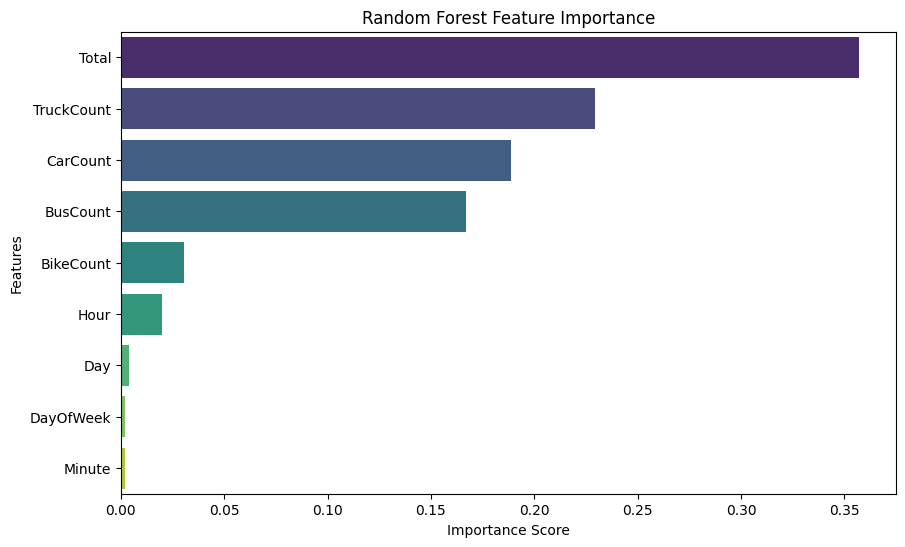


Feature Importance Scores:
   Feature  Importance
     Total    0.357086
TruckCount    0.229321
  CarCount    0.188509
  BusCount    0.166795
 BikeCount    0.030345
      Hour    0.019949
       Day    0.004010
 DayOfWeek    0.002094
    Minute    0.001891


In [ ]:
# Check feature importance
importances = model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

# Print raw importance values
print("\nFeature Importance Scores:")
print(importance_df.to_string(index=False))

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       146
         1.0       1.00      1.00      1.00       748
         2.0       0.99      0.99      0.99        81
         3.0       1.00      1.00      1.00       216

    accuracy                           1.00      1191
   macro avg       1.00      1.00      1.00      1191
weighted avg       1.00      1.00      1.00      1191


Confusion Matrix:
[[146   0   0   0]
 [  0 746   1   1]
 [  0   1  80   0]
 [  0   0   0 216]]


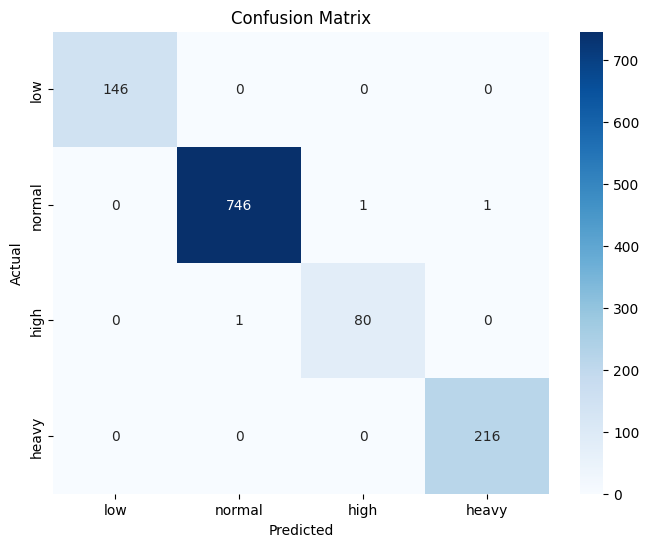

In [ ]:
# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 2))

# Classification report (includes precision, recall, F1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
labels = [0, 1, 2, 3]
class_names = ['low', 'normal', 'high', 'heavy']
cm = confusion_matrix(y_test, y_pred, labels=labels)
print("\nConfusion Matrix:")
print(cm)

# Plot it nicely
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Drop feature(s) with zero importance
df.drop(columns=['Month'], inplace=True)

In [ ]:
# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=5,  # 5-fold cross-validation
    n_jobs=-1,  # Use all cores for faster search
    verbose=1   # Shows progress
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best F1 Score:", round(grid_search.best_score_, 4))

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best F1 Score: 0.997


Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       146
         1.0       1.00      1.00      1.00       748
         2.0       0.99      0.98      0.98        81
         3.0       1.00      1.00      1.00       216

    accuracy                           1.00      1191
   macro avg       1.00      0.99      0.99      1191
weighted avg       1.00      1.00      1.00      1191


Confusion Matrix:
[[146   0   0   0]
 [  0 746   1   1]
 [  0   2  79   0]
 [  0   0   0 216]]


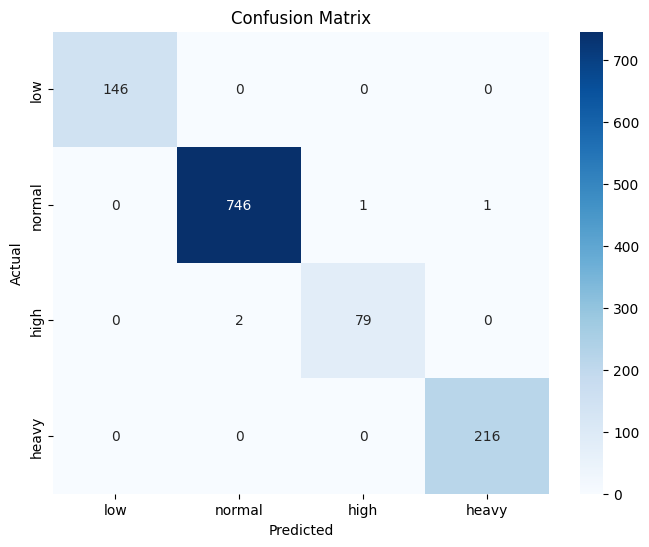

In [ ]:
# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 2))

# Classification report (includes precision, recall, F1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
labels = [0, 1, 2, 3]
class_names = ['low', 'normal', 'high', 'heavy']
cm = confusion_matrix(y_test, y_pred, labels=labels)
print("\nConfusion Matrix:")
print(cm)

# Plot it nicely
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()



---



Logistic Regression

In [ ]:
#Import logisticRegression from sklearn.linear_model
from sklearn.linear_model import LogisticRegression

# Create a Logistic Regression model
model = LogisticRegression(max_iter=1000, solver='lbfgs')

# Train the model using the training data
model.fit(X_train, y_train)

# Make predictions on Xtest
y_pred = model.predict(X_test)

/tmp/ipython-input-18-1923336454.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


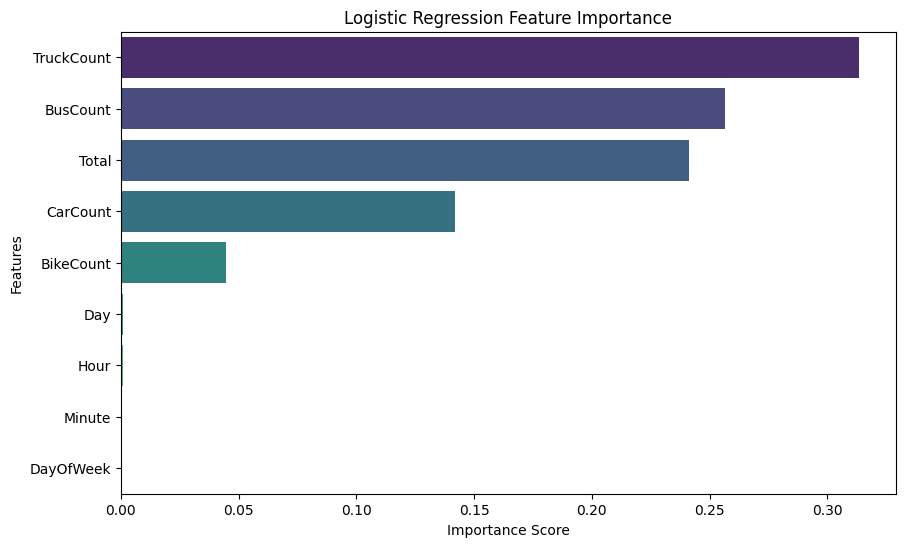


Feature Importance (Logistic Regression):
       CarCount: 0.141766
      BikeCount: 0.044657
       BusCount: 0.256430
     TruckCount: 0.313478
          Total: 0.241155
            Day: 0.000719
           Hour: 0.000717
         Minute: 0.000541
      DayOfWeek: 0.000537


In [ ]:
# Get feature importance
feature_importance = np.abs(model.coef_[0])
feature_importance = feature_importance / feature_importance.sum()

feature_names = X_train.columns

# Create a DataFrame for visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Logistic Regression Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

# Create simple display (higher = more important)
print("\nFeature Importance (Logistic Regression):")
for feature, importance in zip(X_train.columns, feature_importance):
    print(f"{feature:>15}: {importance:.6f}")

Accuracy: 0.88

Classification Report:
              precision    recall  f1-score   support

         0.0       0.79      0.72      0.75       146
         1.0       0.90      0.93      0.91       748
         2.0       0.67      0.48      0.56        81
         3.0       0.95      0.98      0.97       216

    accuracy                           0.88      1191
   macro avg       0.83      0.78      0.80      1191
weighted avg       0.88      0.88      0.88      1191


Confusion Matrix:
[[105  41   0   0]
 [ 28 697  16   7]
 [  0  38  39   4]
 [  0   1   3 212]]


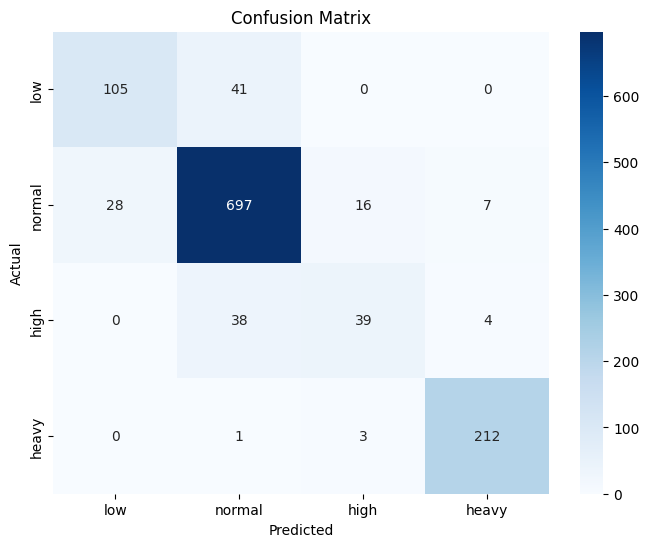

In [ ]:
# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 2))

# Classification report (includes precision, recall, F1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
labels = [0, 1, 2, 3]
class_names = ['low', 'normal', 'high', 'heavy']
cm = confusion_matrix(y_test, y_pred, labels=labels)
print("\nConfusion Matrix:")
print(cm)

# Plot it nicely
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
log_reg = LogisticRegression(max_iter=1000)

param_grid_log = {
    'C': [0.01, 0.1, 1, 10, 100],  # Regularization strength
    'solver': ['lbfgs', 'liblinear'],  # Optimization algorithm
    'penalty': ['l2']  # 'l1' works with 'liblinear' only
}

grid_log = GridSearchCV(log_reg, param_grid_log, cv=5, scoring='accuracy', n_jobs=-1)
grid_log.fit(X_train, y_train)

print("Best Logistic Regression Params:", grid_log.best_params_)
print("Best Logistic Regression Score:", grid_log.best_score_)

best_log_model = grid_log.best_estimator_
y_pred = best_log_model.predict(X_test)

Best Logistic Regression Params: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Best Logistic Regression Score: 0.8867882934915834


Accuracy: 0.88

Classification Report:
              precision    recall  f1-score   support

         0.0       0.78      0.73      0.75       146
         1.0       0.90      0.93      0.91       748
         2.0       0.68      0.51      0.58        81
         3.0       0.96      0.99      0.97       216

    accuracy                           0.88      1191
   macro avg       0.83      0.79      0.80      1191
weighted avg       0.88      0.88      0.88      1191


Confusion Matrix:
[[106  40   0   0]
 [ 30 694  17   7]
 [  0  37  41   3]
 [  0   1   2 213]]


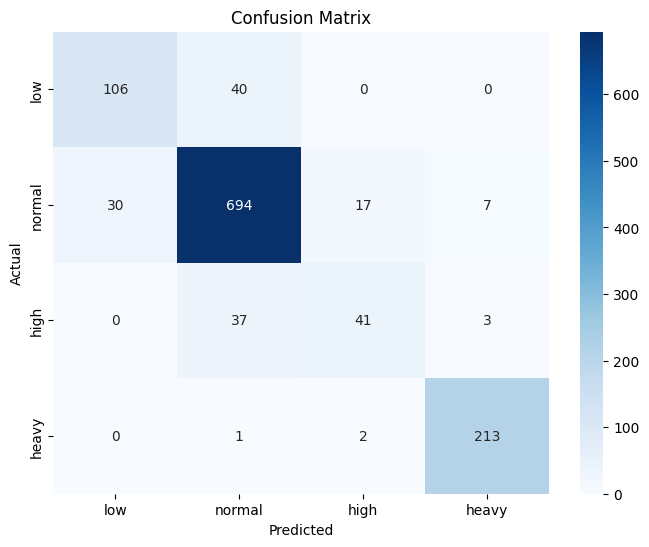

In [ ]:
# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 2))

# Classification report (includes precision, recall, F1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
labels = [0, 1, 2, 3]
class_names = ['low', 'normal', 'high', 'heavy']
cm = confusion_matrix(y_test, y_pred, labels=labels)
print("\nConfusion Matrix:")
print(cm)

# Plot it nicely
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()



---



XGBoost

In [ ]:
from xgboost import XGBClassifier

# Initialize XGBoost
model = XGBClassifier(n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

/tmp/ipython-input-26-1316344997.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


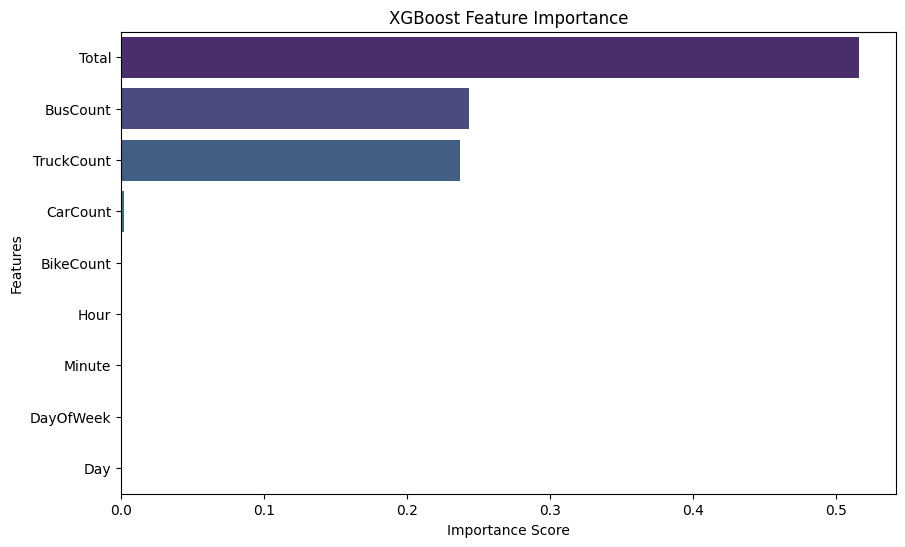


Feature Importance Scores:
   Feature  Importance
     Total    0.515816
  BusCount    0.243426
TruckCount    0.237167
  CarCount    0.002017
 BikeCount    0.000756
      Hour    0.000582
    Minute    0.000115
 DayOfWeek    0.000099
       Day    0.000022


In [ ]:
# Check feature importance
importances = model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

# Print raw importance values
print("\nFeature Importance Scores:")
print(importance_df.to_string(index=False))

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       146
         1.0       1.00      1.00      1.00       748
         2.0       0.99      1.00      0.99        81
         3.0       1.00      1.00      1.00       216

    accuracy                           1.00      1191
   macro avg       1.00      1.00      1.00      1191
weighted avg       1.00      1.00      1.00      1191


Confusion Matrix:
[[146   0   0   0]
 [  0 747   1   0]
 [  0   0  81   0]
 [  0   0   0 216]]


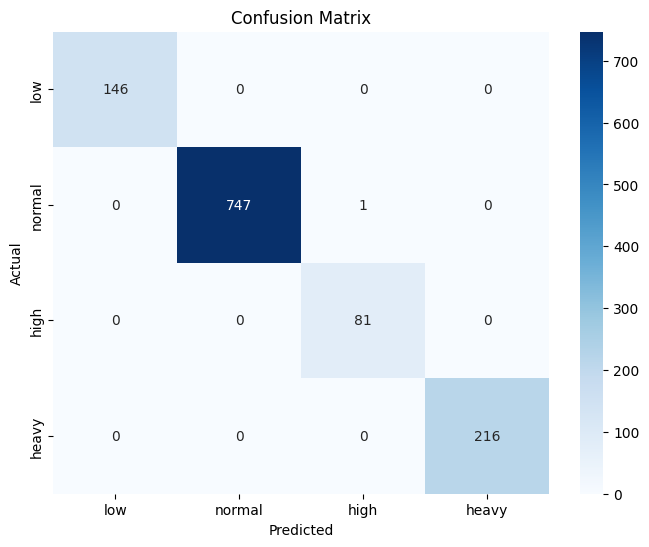

In [ ]:
# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 2))

# Classification report (includes precision, recall, F1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
labels = [0, 1, 2, 3]
class_names = ['low', 'normal', 'high', 'heavy']
cm = confusion_matrix(y_test, y_pred, labels=labels)
print("\nConfusion Matrix:")
print(cm)

# Plot it nicely
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 150],         # Number of trees
    'max_depth': [3, 5, 7],                 # Depth of each tree
    'learning_rate': [0.01, 0.1, 0.2],      # How fast the model learns
    'subsample': [0.8, 1.0],                # % of data used per tree
    'colsample_bytree': [0.8, 1.0]          # % of features used per tree
}

xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='f1_macro',      # Or 'accuracy' or any other metric
    cv=5,                    # 5-fold cross-validation
    n_jobs=-1,               # Use all CPU cores
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best F1 Score:", round(grid_search.best_score_, 4))

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [16:15:06] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 150, 'subsample': 1.0}
Best F1 Score: 0.9994


Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       146
         1.0       1.00      1.00      1.00       748
         2.0       0.99      1.00      0.99        81
         3.0       1.00      1.00      1.00       216

    accuracy                           1.00      1191
   macro avg       1.00      1.00      1.00      1191
weighted avg       1.00      1.00      1.00      1191


Confusion Matrix:
[[146   0   0   0]
 [  0 747   1   0]
 [  0   0  81   0]
 [  0   0   0 216]]


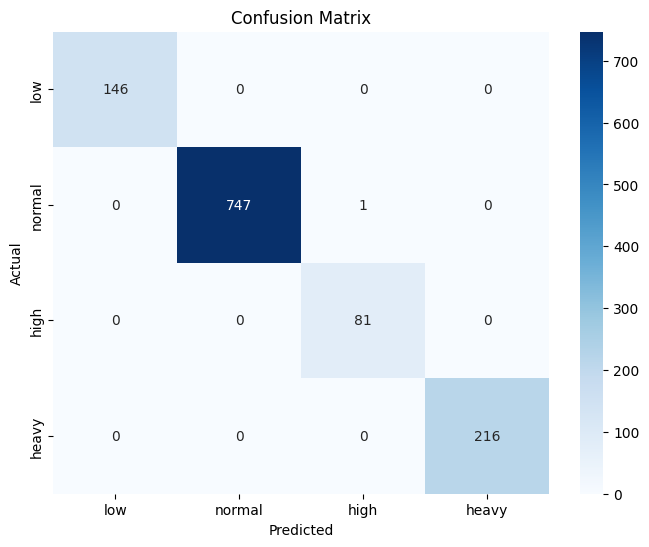

In [ ]:
# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 2))

# Classification report (includes precision, recall, F1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
labels = [0, 1, 2, 3]
class_names = ['low', 'normal', 'high', 'heavy']
cm = confusion_matrix(y_test, y_pred, labels=labels)
print("\nConfusion Matrix:")
print(cm)

# Plot it nicely
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()



---



Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=10, random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

/tmp/ipython-input-32-3619992267.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


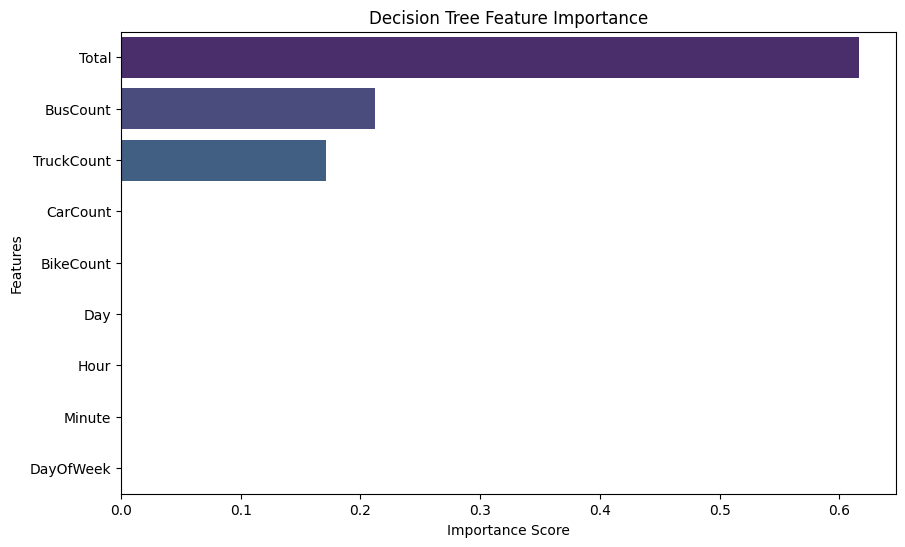


Feature Importance Scores:
   Feature  Importance
     Total    0.616310
  BusCount    0.212292
TruckCount    0.171398
  CarCount    0.000000
 BikeCount    0.000000
       Day    0.000000
      Hour    0.000000
    Minute    0.000000
 DayOfWeek    0.000000


In [ ]:
# Check feature importance
importances = model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Decision Tree Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

# Print raw importance values
print("\nFeature Importance Scores:")
print(importance_df.to_string(index=False))

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       146
         1.0       1.00      1.00      1.00       748
         2.0       0.99      0.99      0.99        81
         3.0       1.00      1.00      1.00       216

    accuracy                           1.00      1191
   macro avg       1.00      1.00      1.00      1191
weighted avg       1.00      1.00      1.00      1191


Confusion Matrix:
[[146   0   0   0]
 [  0 747   1   0]
 [  0   1  80   0]
 [  0   0   0 216]]


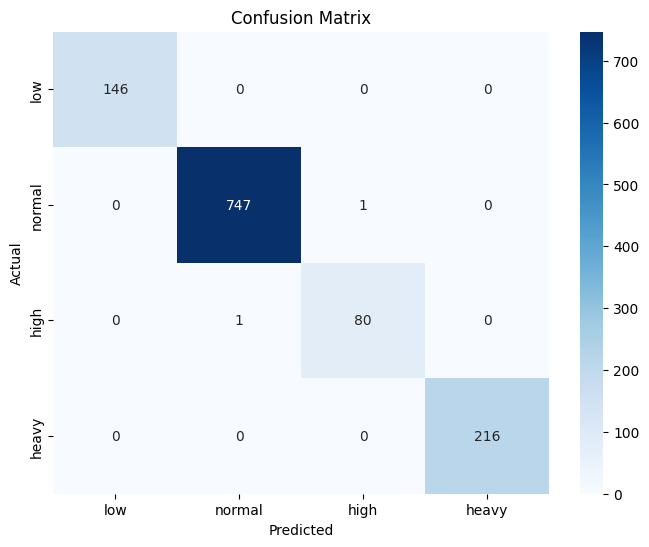

In [ ]:
# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 2))

# Classification report (includes precision, recall, F1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
labels = [0, 1, 2, 3]
class_names = ['low', 'normal', 'high', 'heavy']
cm = confusion_matrix(y_test, y_pred, labels=labels)
print("\nConfusion Matrix:")
print(cm)

# Plot it nicely
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

dt = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    scoring='f1_macro',     # or 'accuracy', 'recall_macro', etc.
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best F1 Score (CV):", round(grid_search.best_score_, 4))

# Evaluate on test set
best_dt = grid_search.best_estimator_
y_pred = best_dt.predict(X_test)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best F1 Score (CV): 0.9995


Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       146
         1.0       1.00      1.00      1.00       748
         2.0       0.99      0.99      0.99        81
         3.0       1.00      1.00      1.00       216

    accuracy                           1.00      1191
   macro avg       1.00      1.00      1.00      1191
weighted avg       1.00      1.00      1.00      1191


Confusion Matrix:
[[146   0   0   0]
 [  0 747   1   0]
 [  0   1  80   0]
 [  0   0   0 216]]


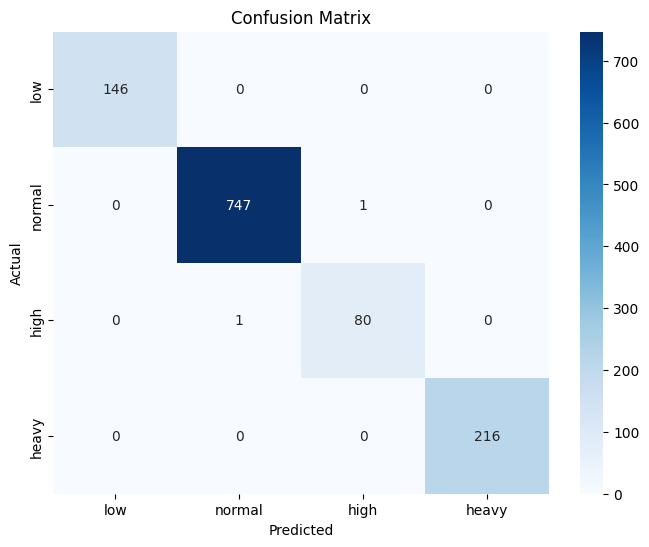

In [ ]:
# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 2))

# Classification report (includes precision, recall, F1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
labels = [0, 1, 2, 3]
class_names = ['low', 'normal', 'high', 'heavy']
cm = confusion_matrix(y_test, y_pred, labels=labels)
print("\nConfusion Matrix:")
print(cm)

# Plot it nicely
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()



---



SVC

In [ ]:
from sklearn.svm import LinearSVC

model = LinearSVC(max_iter=10000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

/tmp/ipython-input-38-2901456680.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


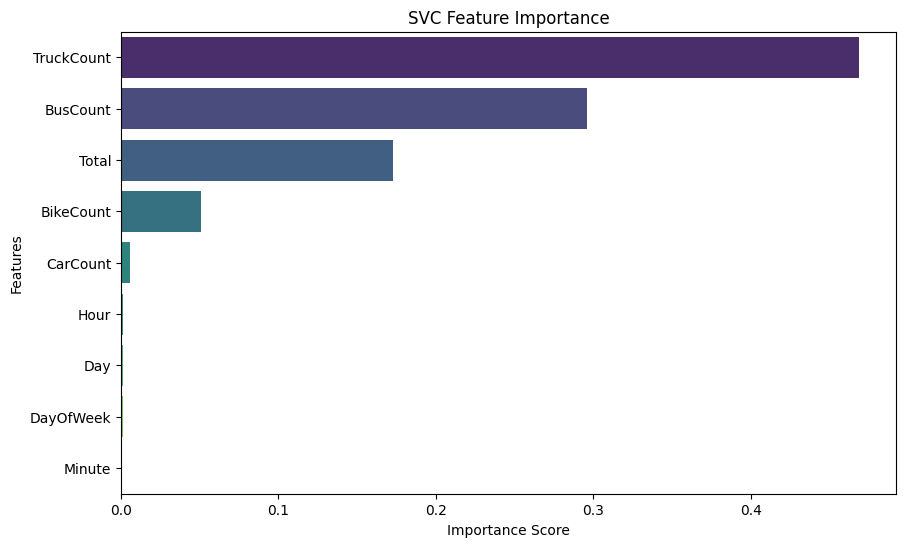


Feature Importance (Logistic Regression):
       CarCount: 0.005682
      BikeCount: 0.051039
       BusCount: 0.296204
     TruckCount: 0.468692
          Total: 0.173013
            Day: 0.001529
           Hour: 0.001570
         Minute: 0.000856
      DayOfWeek: 0.001414


In [ ]:
# Get feature importance
feature_importance = np.abs(model.coef_[0])
feature_importance = feature_importance / feature_importance.sum()

feature_names = X_train.columns

# Create a DataFrame for visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('SVC Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

# Create simple display (higher = more important)
print("\nFeature Importance (SVC):")
for feature, importance in zip(X_train.columns, feature_importance):
    print(f"{feature:>15}: {importance:.6f}")

Accuracy: 0.84

Classification Report:
              precision    recall  f1-score   support

         0.0       0.77      0.56      0.65       146
         1.0       0.83      0.95      0.89       748
         2.0       0.00      0.00      0.00        81
         3.0       0.91      0.97      0.94       216

    accuracy                           0.84      1191
   macro avg       0.63      0.62      0.62      1191
weighted avg       0.78      0.84      0.81      1191


Confusion Matrix:
[[ 82  64   0   0]
 [ 24 711   0  13]
 [  0  74   0   7]
 [  0   6   0 210]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


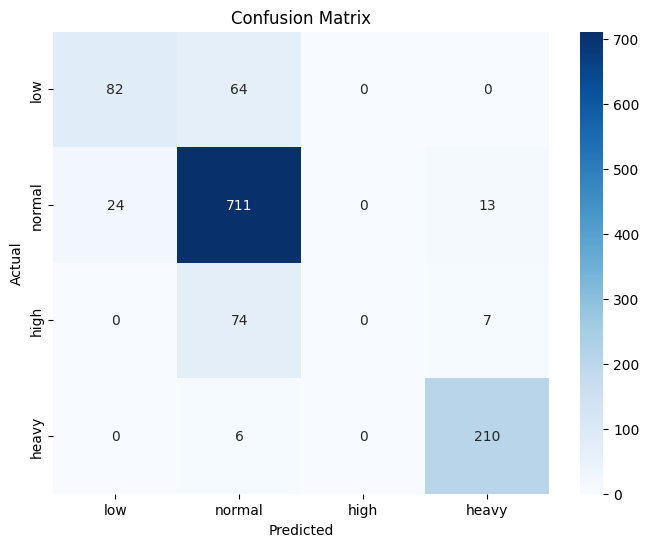

In [ ]:
# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 2))

# Classification report (includes precision, recall, F1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
labels = [0, 1, 2, 3]
class_names = ['low', 'normal', 'high', 'heavy']
cm = confusion_matrix(y_test, y_pred, labels=labels)
print("\nConfusion Matrix:")
print(cm)

# Plot it nicely
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid_linear_svc = {
    'C': [0.01, 0.1, 1, 10, 100],
    'loss': ['hinge', 'squared_hinge'],
    'penalty': ['l2'],
    'dual': [False, True]  # False when n_samples > n_features often helps
}

grid_linear_svc = GridSearchCV(model, param_grid_linear_svc, cv=5, scoring='accuracy', n_jobs=-1)
grid_linear_svc.fit(X_train, y_train)

print("Best LinearSVC Params:", grid_linear_svc.best_params_)
print("Best LinearSVC Score:", grid_linear_svc.best_score_)

best_svc_model = grid_linear_svc.best_estimator_
y_pred = best_svc_model.predict(X_test)

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
25 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/svm/_classes.py", line 321, in fit
    self.coef_, self.intercept_, n_i

Best LinearSVC Params: {'C': 1, 'dual': True, 'loss': 'hinge', 'penalty': 'l2'}
Best LinearSVC Score: 0.850453896143977


/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Accuracy: 0.85

Classification Report:
              precision    recall  f1-score   support

         0.0       0.76      0.66      0.71       146
         1.0       0.85      0.95      0.89       748
         2.0       0.50      0.02      0.05        81
         3.0       0.93      0.97      0.95       216

    accuracy                           0.85      1191
   macro avg       0.76      0.65      0.65      1191
weighted avg       0.83      0.85      0.82      1191


Confusion Matrix:
[[ 97  49   0   0]
 [ 30 707   2   9]
 [  0  72   2   7]
 [  0   7   0 209]]


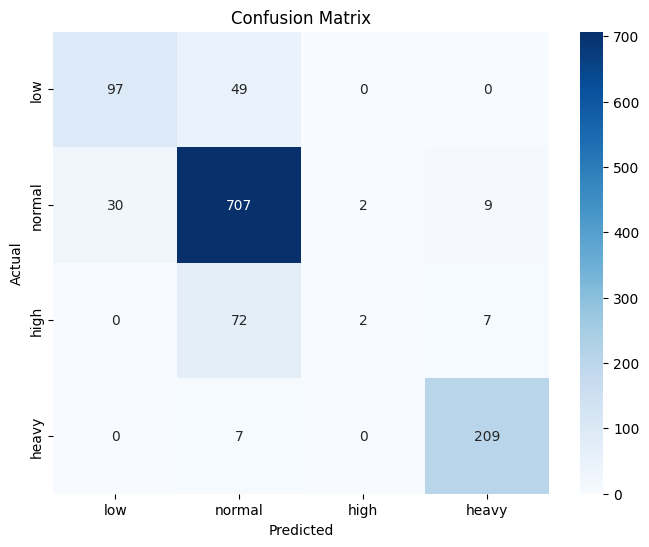

In [ ]:
# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 2))

# Classification report (includes precision, recall, F1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
labels = [0, 1, 2, 3]
class_names = ['low', 'normal', 'high', 'heavy']
cm = confusion_matrix(y_test, y_pred, labels=labels)
print("\nConfusion Matrix:")
print(cm)

# Plot it nicely
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()